In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
llm = ChatGroq(model="openai/gpt-oss-20b")


In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [7]:
def generate_joke(state: JokeState):

    prompt = f'Generate a joke on {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

def generate_explanation(state: JokeState):

    prompt = f'Give an appropriate explanation to the following joke : \n {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}



In [21]:
# define a graph
graph = StateGraph(JokeState)

# add nodes to the graph
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# add edges to the graph
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


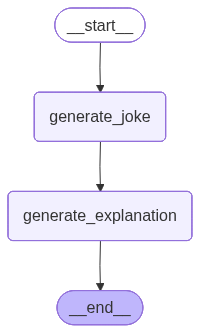

In [22]:
workflow

In [24]:
config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'tomato rice'}, config=config1)

{'topic': 'tomato rice',
 'joke': 'Why did the tomato rice go to therapy?\n\nBecause it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!',
 'explanation': '**Explanation of the joke**\n\n> *Why did the tomato rice go to therapy?  \n>  Because it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!*\n\n| Element | What it does | Why it’s funny |\n|---------|--------------|----------------|\n| **Anthropomorphism** | Treats a dish (“tomato rice”) as if it were a person who can feel emotions and seek therapy. | The absurdity of a food item needing counseling creates a playful, “groan‑worthy” tone that many people find endearing. |\n| **Double meaning of “jam”** | 1️⃣ “Stuck in a jam” is a common idiom for being trapped or in trouble. 2️⃣ “Jam” is also a sweet fruit preserve that’s literally sticky. | The joke relies on the reader’s awareness that “jam” can mean both a sticky situation and a food product, so the phrase feel

In [25]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'tomato rice', 'joke': 'Why did the tomato rice go to therapy?\n\nBecause it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!', 'explanation': '**Explanation of the joke**\n\n> *Why did the tomato rice go to therapy?  \n>  Because it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!*\n\n| Element | What it does | Why it’s funny |\n|---------|--------------|----------------|\n| **Anthropomorphism** | Treats a dish (“tomato rice”) as if it were a person who can feel emotions and seek therapy. | The absurdity of a food item needing counseling creates a playful, “groan‑worthy” tone that many people find endearing. |\n| **Double meaning of “jam”** | 1️⃣ “Stuck in a jam” is a common idiom for being trapped or in trouble. 2️⃣ “Jam” is also a sweet fruit preserve that’s literally sticky. | The joke relies on the reader’s awareness that “jam” can mean both a sticky situation and a food product,

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'tomato rice', 'joke': 'Why did the tomato rice go to therapy?\n\nBecause it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!', 'explanation': '**Explanation of the joke**\n\n> *Why did the tomato rice go to therapy?  \n>  Because it felt it was always being “stuck in a jam” and couldn’t ketchup with its true flavor!*\n\n| Element | What it does | Why it’s funny |\n|---------|--------------|----------------|\n| **Anthropomorphism** | Treats a dish (“tomato rice”) as if it were a person who can feel emotions and seek therapy. | The absurdity of a food item needing counseling creates a playful, “groan‑worthy” tone that many people find endearing. |\n| **Double meaning of “jam”** | 1️⃣ “Stuck in a jam” is a common idiom for being trapped or in trouble. 2️⃣ “Jam” is also a sweet fruit preserve that’s literally sticky. | The joke relies on the reader’s awareness that “jam” can mean both a sticky situation and a food product

In [27]:
config2 = {'configurable': {'thread_id': '2'}}
workflow.invoke({'topic': 'biryani'}, config=config2)

{'topic': 'biryani',
 'joke': 'Why did the biryani apply for a job?\n\nBecause it heard the position was “seasoned” and it wanted to spice up its résumé!',
 'explanation': '**Explanation of the joke**\n\nThe joke plays on the double meaning of the word *seasoned* and on the idea that a résumé (or CV) can be “spiced up” to make it more impressive.\n\n1. **Seasoned**  \n   - **Literal sense**: In cooking, a dish is *seasoned* when it’s flavored with herbs, spices, salt, etc.  \n   - **Figurative sense**: In employment, a *seasoned* candidate is experienced, well‑qualified, or “seasoned” by having worked in the field for a while.\n\n2. **Spice up its résumé**  \n   - **Literal sense**: Adding spices to food makes it tastier.  \n   - **Figurative sense**: Adding interesting details, achievements, or flair to a résumé makes it more attractive to employers.\n\nSo the punchline is a pun: the biryani “heard” (as if it could listen) that the job was “seasoned” (both a cooking term and a job‑sea

In [28]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'biryani', 'joke': 'Why did the biryani apply for a job?\n\nBecause it heard the position was “seasoned” and it wanted to spice up its résumé!', 'explanation': '**Explanation of the joke**\n\nThe joke plays on the double meaning of the word *seasoned* and on the idea that a résumé (or CV) can be “spiced up” to make it more impressive.\n\n1. **Seasoned**  \n   - **Literal sense**: In cooking, a dish is *seasoned* when it’s flavored with herbs, spices, salt, etc.  \n   - **Figurative sense**: In employment, a *seasoned* candidate is experienced, well‑qualified, or “seasoned” by having worked in the field for a while.\n\n2. **Spice up its résumé**  \n   - **Literal sense**: Adding spices to food makes it tastier.  \n   - **Figurative sense**: Adding interesting details, achievements, or flair to a résumé makes it more attractive to employers.\n\nSo the punchline is a pun: the biryani “heard” (as if it could listen) that the job was “seasoned” (both a cooking

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'biryani', 'joke': 'Why did the biryani apply for a job?\n\nBecause it heard the position was “seasoned” and it wanted to spice up its résumé!', 'explanation': '**Explanation of the joke**\n\nThe joke plays on the double meaning of the word *seasoned* and on the idea that a résumé (or CV) can be “spiced up” to make it more impressive.\n\n1. **Seasoned**  \n   - **Literal sense**: In cooking, a dish is *seasoned* when it’s flavored with herbs, spices, salt, etc.  \n   - **Figurative sense**: In employment, a *seasoned* candidate is experienced, well‑qualified, or “seasoned” by having worked in the field for a while.\n\n2. **Spice up its résumé**  \n   - **Literal sense**: Adding spices to food makes it tastier.  \n   - **Figurative sense**: Adding interesting details, achievements, or flair to a résumé makes it more attractive to employers.\n\nSo the punchline is a pun: the biryani “heard” (as if it could listen) that the job was “seasoned” (both a cookin